
############################################################################
# Implementación del método CVV para la clasificación del dataset CIFAR-10
# Autor: Jaime Duque Domingo
############################################################################

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


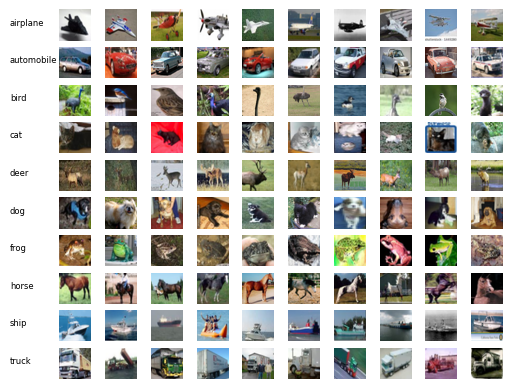

In [1]:
# -*- coding: utf-8 -*-
# Permitir llamadas duplicadas a librería
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
# Cargamos numpy
import numpy as np
# Cargamos datasets de torchvision
from torchvision import datasets
# Cargamos Matplotlib para representar gráficamente el entrenamiento
import matplotlib.pyplot as plt

# Cargamos el dataset CIFAR-10
dataset = datasets.CIFAR10('data', train=True, download= True)

# Lista de clases
clases = dataset.classes

# Posición de la imagen en el plot
posicion = 0
for c in range(len(clases)):
    # Buscamos las imágenes con esta clase
    indices = np.where(np.asarray(dataset.targets) == c)[0]

    # Escribimos etiqueta de clase
    posicion += 1
    plt.subplot(10, 11, posicion)
    plt.text(0, 0.5, clases[c], fontsize=6)
    plt.axis('off')

    # Sacamos 10 imágenes de cada categoría por fila
    for i in range(10):
        posicion += 1
        plt.subplot(10, 11, posicion)
        plt.imshow(dataset.data[indices[i]])
        plt.axis('off')
plt.savefig("imagenesCIFAR.pdf", format="pdf")
plt.show()


EJEMPLOS DE USO

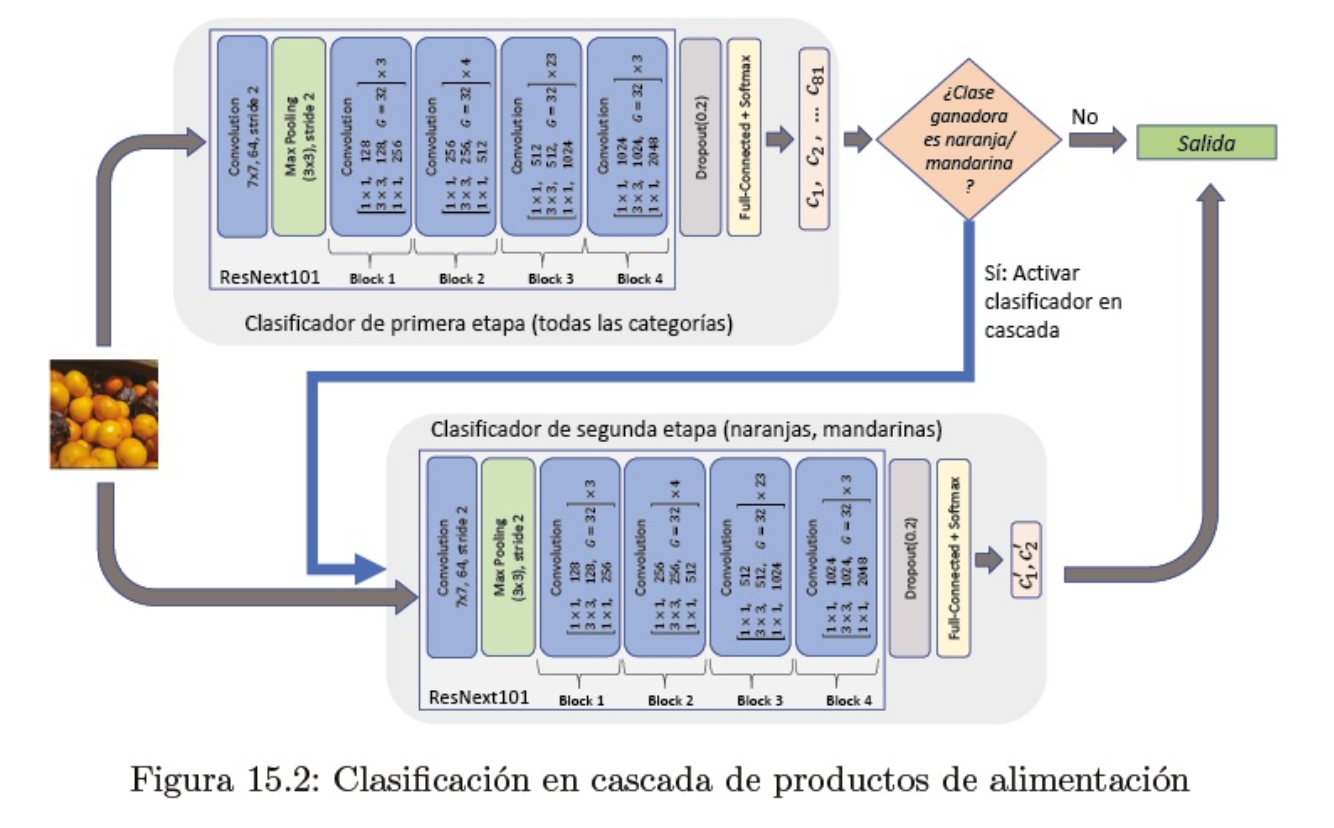

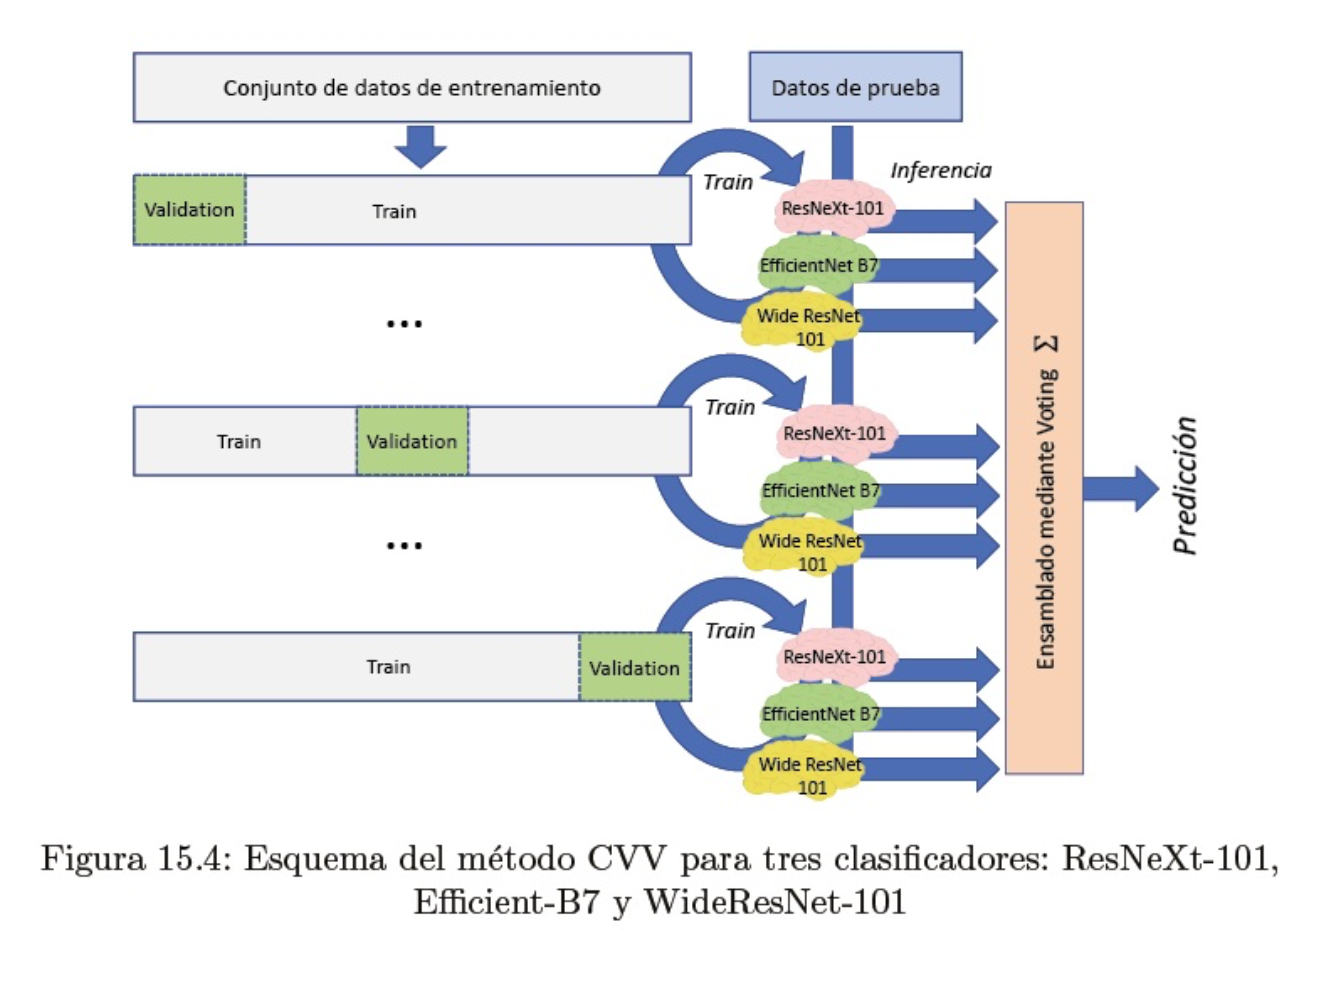

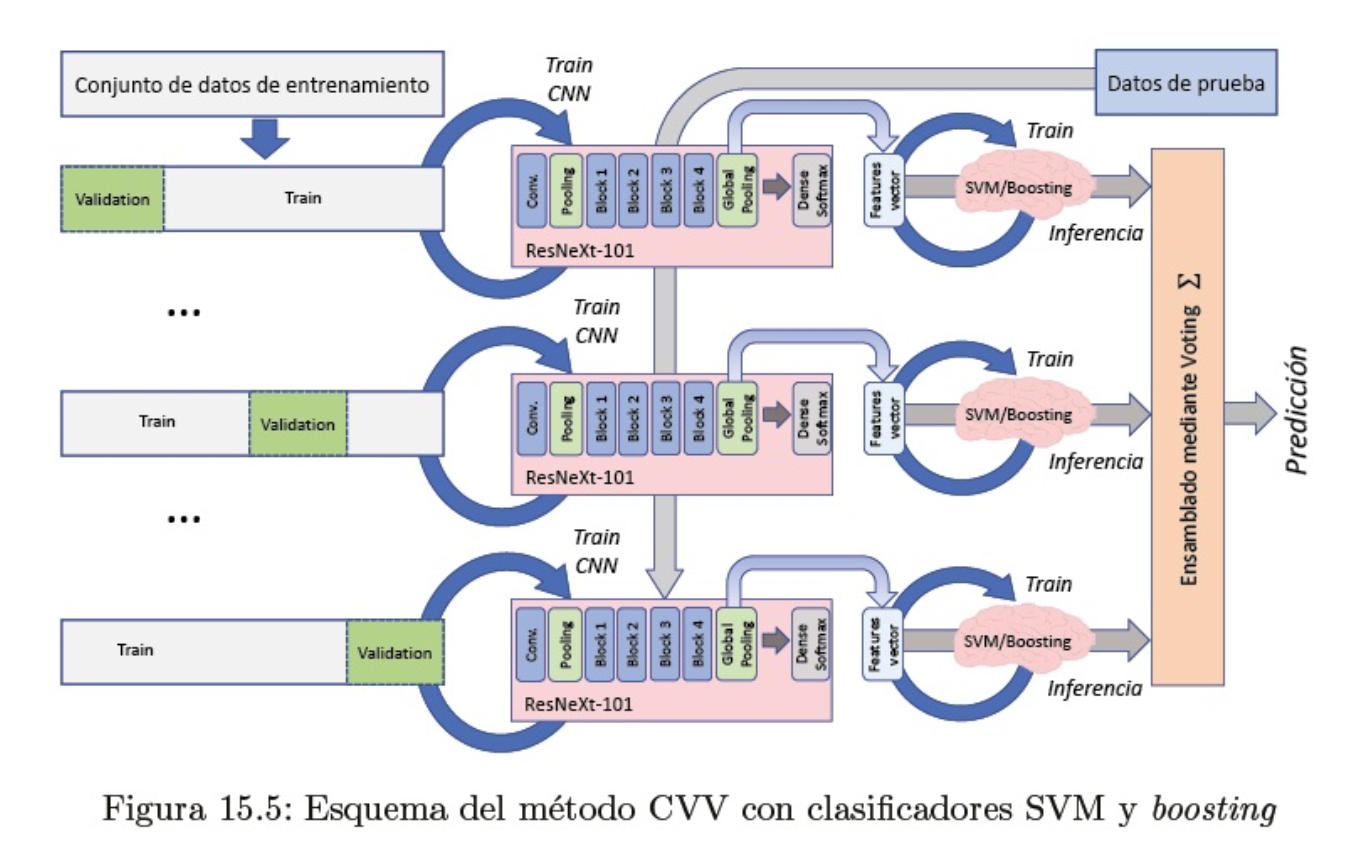

In [2]:
# Cargamos la librería de tiempo
import time
# Cargamos Pytorch
import torch
from torch import nn
from torch.nn import functional as F
# Cargamos torchvision
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Ver si está la GPU disponible
print("GPU disponible: ", torch.cuda.is_available())
uso_gpu = torch.cuda.is_available()


GPU disponible:  True


In [3]:
# Definimos variables de nuestro modelo
batch_size, epocas = 100, 20
num_workers = 0

# Definimos una transformación, que pasa la imagen a un tensor y la normaliza en intervalo [-1, 1]

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Cargamos el dataset CIFAR-10 aplicando la transformación
train_data = datasets.CIFAR10("data", train=True, download= True, transform=transforms)
test_data = datasets.CIFAR10("data", train=False, download= True, transform=transforms)

# Lista de clases
clases = train_data.classes


In [4]:
#####################################################
# Generamos K repartos de entrenamiento y validación
#####################################################
# Definimos el número de conjuntos de validación. Esto implicará K entrenamientos
K = 5

tam_total = len(train_data)

# Repartimos los índices de manera aleatoria
indices = list(range(tam_total))
np.random.shuffle(indices)

train_idx = []
val_idx = []
train_sampler = []
val_sampler = []

# Creamos un dataloader de train y val para cada slot
train_loader = []
val_loader = []

for i in range(K):
    inicio = int(i * tam_total / K)
    final = int(inicio + tam_total / K)
    # Vamos creando los slots de validación
    val_idx.append( indices[inicio:final] )
    # En el slot de train dejamos los índices que no están en el slot de validación
    train_idx.append( list(set(indices) - set(val_idx[i])) )
    # Creamos los samplers asociados
    train_sampler.append( SubsetRandomSampler(train_idx[i]) )
    val_sampler.append( SubsetRandomSampler(val_idx[i]) )
    # Creamos los dataloaders asociados
    train_loader.append(torch.utils.data.DataLoader(train_data, batch_size=batch_size,
        sampler=train_sampler[i], num_workers=num_workers))
    val_loader.append(torch.utils.data.DataLoader(train_data, batch_size=batch_size,
        sampler=val_sampler[i], num_workers=num_workers))

# Creamos el dataloader de test
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)


In [5]:
########################################################################
# Creamos una función de entrenamiento, donde recorreremos por un lado
# las distintas épocas y por otro lado iteraremos sobre los batch
########################################################################
def train(modelo, train_loader, val_loader, tam_train, tam_val, criterion, optimizer, num_epocas, slot):
    print("Entrenando slot: ", slot)
    # Variable para elegir el mejor modelo ante validación
    val_loss_min = np.inf

    # Listas para guardar nuestro histórico de entrenamiento y validación
    train_accuracies = []
    train_losses = []
    val_accuracies = []
    val_losses = []

    # Iteramos sobre las distintas épocas
    for epoca in range(num_epocas):
        start_time  = time.time()
        print("Epoch {}/{}".format(epoca, num_epocas - 1), flush=True)
        print("-" * 10, flush=True)

        # Creamos unas variables para acumular la pérdida y el accuracy
        # para acumular en los distintos batch (tanto entrenamiento como validación)
        train_loss = 0.0
        train_acc = 0.0
        val_loss = 0.0
        val_acc = 0.0

        # Modo entrenamiento
        modelo.train()
        # Iteramos sobre los batch de cada época
        for inputs, target in train_loader:
            if uso_gpu:
                inputs, target = inputs.cuda(), target.cuda()
            # Ponemos a cero los gradientes
            optimizer.zero_grad()

            # Paso hacia adelante
            outputs = modelo(inputs)
            # Como por defecto Pytorch trabaja con Sparse
            #  Categorical Crossentropy, tenemos que identificar la
            #  clase ganadora. Esta función es equivalente a numpy.argmax
            _, preds = torch.max(outputs, 1)

            # Calculamos el error (criterio que será la Entropía Cruzada)
            loss = criterion(outputs, target)

            # Propagación hacia atrás.
            loss.backward()
            # Avanzamos el optimizador
            optimizer.step()

            # Avanzamos las variables de pérdida y aciertos del batch de entrenamiento
            train_loss +=loss.item() * inputs.size(0)
            train_acc += torch.sum(preds == target.data)

        # Modo evaluación
        modelo.eval()
        for inputs, target in val_loader:
            if uso_gpu:
                inputs, target = inputs.cuda(), target.cuda()
            # Paso hacia adelante únicamente
            outputs = modelo(inputs)
            _, preds = torch.max(outputs, 1)

            # Calculamos el error (criterio que será la Entropía Cruzada)
            loss = criterion(outputs, target)

            # Avanzamos las variables de pérdida y aciertos del batch de validación
            val_loss +=loss.item() * inputs.size(0)
            val_acc += torch.sum(preds == target.data)

        # Avanzamos las variables de pérdida y aciertos de la época
        epoch_train_loss = train_loss / tam_train
        epoch_train_acc = train_acc.double() / tam_train
        epoch_val_loss = val_loss / tam_val
        epoch_val_acc = val_acc.double() / tam_val

        # Guardamos en histórico
        if uso_gpu:
            train_accuracies.append(epoch_train_acc.cpu())
            val_accuracies.append(epoch_val_acc.cpu())
        else:
            train_accuracies.append(epoch_train_acc)
            val_accuracies.append(epoch_val_acc)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        print("Train Loss: {:.4f} Acc: {:.4f}".format(epoch_train_loss, epoch_train_acc), flush=True)
        print("Validation Loss: {:.4f} Acc: {:.4f}".format(epoch_val_loss, epoch_val_acc), flush=True)
        print("Tiempo por época: {:d} segundos\n".format(int(time.time()-start_time)), flush=True)

        # Si el modelo mejora los resultados de validación, lo guardamos
        if epoch_val_loss < val_loss_min:
            print("Encontrado mejor modelo. Pérdida de validación reducida de ",round(val_loss_min,3)," a ", round(epoch_val_loss,3))
            print("Guardando modelo modelo_CIFAR10.pt")
            torch.save(modelo.state_dict(), "modelo_CVV_CIFAR10_slot_" + str(slot) + ".pt")
            val_loss_min = epoch_val_loss

    # Cargamos el mejor de los modelos ante validación
    modelo.load_state_dict(torch.load("modelo_CVV_CIFAR10_slot_" + str(slot) + ".pt"))

    return train_accuracies, train_losses, val_accuracies, val_losses


In [6]:
#################################################
# Definimos nuestro modelo de red convolucional
#################################################
class Mi_Modelo(nn.Module):
    def __init__(self):
        super().__init__()
        # Capas de convolución
        self.conv1 = nn.Conv2d(3,16,3, padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)
        # Capa de pooling
        self.pool = nn.MaxPool2d(2,2)
        # Capas de clasificación
        self.fc1 = nn.Linear(64*4*4,120)
        self.fc2 = nn.Linear(120, 60)
        self.fc3 = nn.Linear(60,10)
        # Capa de dropout
        self.dropout = nn.Dropout(0.25)
        # Función de activación
        self.softmax = nn.Softmax()

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1,64*4*4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        #x = self.softmax(x)
        return x

# Tenemos que entrenar K modelos
modelo = []
for i in range(K):
    modelo.append(Mi_Modelo())
    if uso_gpu:
        modelo[i].cuda()

# Mostramos el primer modelo de ejemplo en pantalla
print("Modelo: ", modelo[0])

Modelo:  Mi_Modelo(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=60, bias=True)
  (fc3): Linear(in_features=60, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (softmax): Softmax(dim=None)
)


In [7]:
##################################################
# Graficamos los entrenamientos generando un PDF
##################################################

def generarGrafico(train_accuracies, val_accuracies, train_losses, val_losses, slot):
    # Representamos gráficamente el entrenamiento mostrando la reducción del error
    plt.clf()
    fig, ax = plt.subplots(2, 1, figsize= (12,6))
    fig.tight_layout(pad=5.0)

    plt.subplot(1,2,1), plt.plot(train_accuracies, 'g', label='Train Accuracy')
    plt.subplot(1,2,1), plt.plot(val_accuracies, 'b', label='Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Época')
    plt.title("Evolución del accuracy del entrenamiento CIFAR-10 (Slot " + str(slot) + ")")
    plt.legend(loc='center right')

    plt.subplot(1,2,2), plt.plot(train_losses, 'r', label='Train Loss')
    plt.subplot(1,2,2), plt.plot(val_losses, 'c', label='Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Época')
    plt.title("Evolución de la pérdida del entrenamiento CIFAR-10 (Slot " + str(slot) + ")")
    plt.legend(loc='center right')

    plt.savefig("errorClasCIFARPytorch_CVV_slot_" + str(slot) + ".pdf", format="pdf")

Entrenando slot:  0
Epoch 0/19
----------
Train Loss: 1.8020 Acc: 0.3273
Validation Loss: 1.4519 Acc: 0.4662
Tiempo por época: 15 segundos

Encontrado mejor modelo. Pérdida de validación reducida de  inf  a  1.452
Guardando modelo modelo_CIFAR10.pt
Epoch 1/19
----------
Train Loss: 1.4620 Acc: 0.4672
Validation Loss: 1.2773 Acc: 0.5334
Tiempo por época: 13 segundos

Encontrado mejor modelo. Pérdida de validación reducida de  1.452  a  1.277
Guardando modelo modelo_CIFAR10.pt
Epoch 2/19
----------
Train Loss: 1.3170 Acc: 0.5257
Validation Loss: 1.1613 Acc: 0.5798
Tiempo por época: 13 segundos

Encontrado mejor modelo. Pérdida de validación reducida de  1.277  a  1.161
Guardando modelo modelo_CIFAR10.pt
Epoch 3/19
----------
Train Loss: 1.2165 Acc: 0.5683
Validation Loss: 1.0743 Acc: 0.6096
Tiempo por época: 13 segundos

Encontrado mejor modelo. Pérdida de validación reducida de  1.161  a  1.074
Guardando modelo modelo_CIFAR10.pt
Epoch 4/19
----------
Train Loss: 1.1394 Acc: 0.5957
Valid

<Figure size 640x480 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

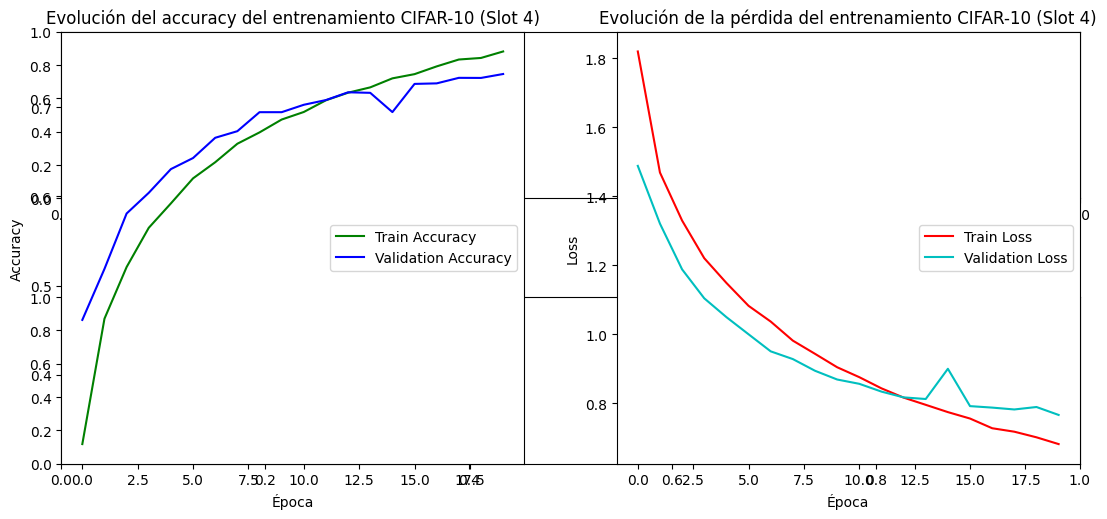

In [8]:
###################################################################
# Llevamos a cabo los K entrenamientos, graficando los resultados
###################################################################
for i in range(K):
    # Definimos función de pérdida como entropía cruzada categórica dispersa
    loss_function = nn.CrossEntropyLoss()
    # El optimizador utilizado es Adam
    optimizer = torch.optim.Adam(modelo[i].parameters(), lr=0.001)

    # Llamamos al entrenamiento
    train_accuracies, train_losses, val_accuracies, val_losses = train(modelo[i], train_loader[i], val_loader[i], len(train_idx[i]), len(val_idx[i]), loss_function, optimizer, epocas, i)
    # Graficamos
    generarGrafico(train_accuracies, val_accuracies, train_losses, val_losses, i)


In [9]:
########################################################
# Evaluación CVV con SOFT-VOTING con los datos de test
########################################################
test_loss = 0.0
test_acc = 0.0

# Modo evaluación
for i in range(K):
    modelo[i].eval()

for inputs, target in test_loader:
    if uso_gpu:
        inputs, target = inputs.cuda(), target.cuda()
    # Paso hacia adelante únicamente. En SV acumulamos las probabilidades
    outputs = modelo[0](inputs)
    for i in range(1, K):
        outputs += modelo[i](inputs)
    # Dividimos las probabilidades acumuladas entre K
    outputs = outputs / K
    _, preds = torch.max(outputs, 1)

    # Calculamos el error (criterio que será la Entropía Cruzada)
    loss = loss_function(outputs, target)

    # Avanzamos las variables de pérdida y aciertos del batch de validación
    test_loss +=loss.item() * inputs.size(0)
    test_acc += torch.sum(preds == target.data)

test_loss = test_loss / len(test_loader.dataset)
test_acc = test_acc.double() / len(test_loader.dataset)

# Mostramos resultado
print("CVV. Soft-Voting con K = 5. Test Loss: {:.4f} Acc: {:.4f}".format(test_loss, test_acc), flush=True)


CVV. Soft-Voting con K = 5. Test Loss: 0.6346 Acc: 0.7825


In [10]:
########################################################
# Evaluación CVV con HARD-VOTING con los datos de test
########################################################
test_loss = 0.0
test_acc = 0.0

for inputs, target in test_loader:
    if uso_gpu:
        inputs, target = inputs.cuda(), target.cuda()
    # Paso hacia adelante únicamente. En HV ponemos a uno los ganadores y a 0 el resto
    outputs = None
    for i in range(K):
        tmp = modelo[i](inputs)
        # Creamos un tensor con todos los valores a 0 similar a la salida del modelo
        output = torch.zeros_like(tmp)
        # En el tensor resultado ponemos a 1 los ganadores
        _, preds = torch.max(tmp, 1)
        for j in range(len(preds)):
            output[j][preds[j]] = 1.0

        if outputs == None:
            outputs = output
        else:
            outputs += output

    # Dividimos las probabilidades acumuladas entre K
    outputs = outputs / K
    _, preds = torch.max(outputs, 1)

    # Calculamos el error (criterio que será la Entropía Cruzada)
    loss = loss_function(outputs, target)

    # Avanzamos las variables de pérdida y aciertos del batch de validación
    test_loss +=loss.item() * inputs.size(0)
    test_acc += torch.sum(preds == target.data)

test_loss = test_loss / len(test_loader.dataset)
test_acc = test_acc.double() / len(test_loader.dataset)

# Mostramos resultado
print("CVV. Hard-Voting con K = 5. Test Loss: {:.4f} Acc: {:.4f}".format(test_loss, test_acc), flush=True)


CVV. Hard-Voting con K = 5. Test Loss: 1.7096 Acc: 0.7755
